In [1]:
import xarray as xr
import os, sys, json 

DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from evaluate import *
from funcshape.surface import PointCloudSurface
from funcshape.visual import plot_surface
import matplotlib.pyplot as plt 

In [2]:
RESULTS_DIR = "../benchmarking/v2.0/results_206_measurements/"

In [3]:
ds = xr.load_dataset(RESULTS_DIR+"/P0/0/ds.nc")

In [4]:
boundaries = find_boundary_points(
    ds.design_space_grid.to_numpy()[:,[0,2,1]], 
    ds.phase_mean.to_numpy()
    )

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


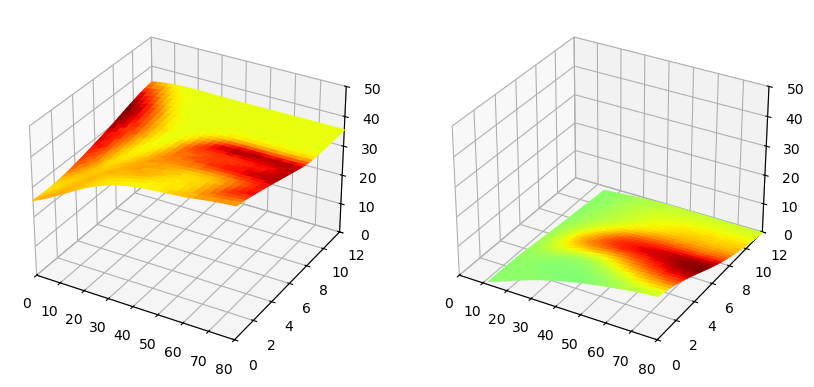

In [5]:
query_01 = PointCloudSurface(boundaries[(0,1)])
query_12 = PointCloudSurface(boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(5*2, 5), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(query_01, ax = axs[0])
plot_surface(query_12, ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

In [6]:
ref_boundaries, ref_surfaces = get_ground_truth_boundaries()

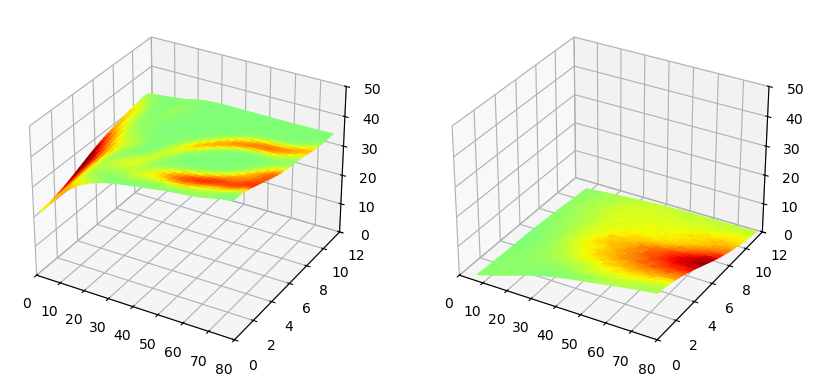

In [7]:
fig, axs = plt.subplots(
    1,2,
    figsize=(5*2, 5), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(ref_surfaces[(0,1)], ax = axs[0])
plot_surface(ref_surfaces[(1,2)], ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 80.0])
    ax.set_ylim([0.0, 12.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

In [8]:
dists = get_boundaries_geodesic_distance(ds.design_space_grid, ds.phase_mean)
print("Distances between query and reference boundaries : ", dists)

2025-10-27 14:53:42 - INFO - [evaluate.py] - Boundary (0, 1): 935 points
2025-10-27 14:53:42 - INFO - [evaluate.py] - Boundary (1, 2): 790 points
2025-10-27 14:53:42 - INFO - [evaluate.py] - Evaluating boundary (0, 1)
2025-10-27 14:53:47 - INFO - [evaluate.py] - Evaluating boundary (1, 2)


Distances between query and reference boundaries :  {(0, 1): 139.31170654296875, (1, 2): 47.67922592163086}


In [9]:
file = RESULTS_DIR+"/P0/0/dists.json"
records = []
with open(file, "r") as f:
    for line in f:
        line = line.strip()
        if line:  # skip empty lines
            records.append(json.loads(line))

print("Final distances computed during phase mapping: ", records[-1])

Final distances computed during phase mapping:  {'(0, 1)': 100.4997023141445, '(1, 2)': 21.242070046605242}


In [10]:
get_baseline_geodesics(n_runs=10)

2025-10-27 14:53:52 - INFO - [evaluate.py] - Baseline geodesic computation run 0/10
2025-10-27 14:54:01 - INFO - [evaluate.py] - Boundary (0, 1): 1895 points
2025-10-27 14:54:01 - INFO - [evaluate.py] - Boundary (1, 2): 1288 points
2025-10-27 14:54:01 - INFO - [evaluate.py] - Evaluating boundary (0, 1)


[Iter     1] loss: 26.433647
[Iter     2] loss: 26.278849
[Iter     3] loss: 26.190710
[Iter     4] loss: 25.771408


2025-10-27 14:54:11 - INFO - [evaluate.py] - Evaluating boundary (1, 2)


[Iter     5] loss: 25.775200
Finished training in 5.55843s
[Iter     1] loss: 50.297577


2025-10-27 14:54:17 - INFO - [evaluate.py] - Baseline geodesic computation run 1/10


...

2025-10-27 14:57:54 - INFO - [evaluate.py] - Boundary (0, 1): 1895 points
2025-10-27 14:57:54 - INFO - [evaluate.py] - Boundary (1, 2): 1288 points
2025-10-27 14:57:54 - INFO - [evaluate.py] - Evaluating boundary (0, 1)


[Iter     1] loss: 28.100376
[Iter     2] loss: 25.744202
[Iter     3] loss: 25.186628


2025-10-27 14:58:04 - INFO - [evaluate.py] - Evaluating boundary (1, 2)


[Iter     4] loss: 25.186628
Finished training in 4.30903s
[Iter     1] loss: 49.929077
[Iter     2] loss: 48.919395
[Iter     3] loss: 48.871872
Finished training in 3.42116s


[{(0, 1): 25.77519989013672, (1, 2): 50.297576904296875},
 {(0, 1): 26.20052719116211, (1, 2): 47.58836364746094},
 {(0, 1): 27.9176025390625, (1, 2): 54.598960876464844},
 {(0, 1): 28.73172378540039, (1, 2): 47.559364318847656},
 {(0, 1): 26.371822357177734, (1, 2): 52.65379333496094},
 {(0, 1): 23.63775634765625, (1, 2): 50.9980354309082},
 {(0, 1): 31.22964096069336, (1, 2): 52.86498260498047},
 {(0, 1): 28.293506622314453, (1, 2): 51.67885971069336},
 {(0, 1): 27.94640350341797, (1, 2): 47.59096908569336},
 {(0, 1): 25.186628341674805, (1, 2): 48.87187194824219}]